# Denoising Diffusion Probabilistic Model for generating images of moon

**Abbreviated: DDPM Ho et al 2020" had introduced a new standard baseling for image generation. I'm using this architecture in this project. A mention to hackclub.com and the YSWS where I'm shipping this - 3am.hackclub.com is well deserved. I will now proceed explaining my notebook and skip the mathematical models.**

In [1]:
import torch
from torch import nn
from torch.optim import Adam
from torch.nn import functional as F
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.utils as vutils
import torchvision.transforms as T
from torchvision.datasets import ImageFolder
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import glob,os,math
from tqdm import tqdm

Cloning my repository to get access of the dataset from my GitHub

In [2]:
!git clone https://github.com/ChinmoyGitPy/Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon.git

Cloning into 'Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon'...
remote: Enumerating objects: 1369, done.
remote: Counting objects: 100% (1369/1369), done.
remote: Compressing objects: 100% (1334/1334), done.
remote: Total 1369 (delta 41), reused 1360 (delta 35), pack-reused 0 (from 0)
Receiving objects: 100% (1369/1369), 17.05 MiB | 29.14 MiB/s, done.
Resolving deltas: 100% (41/41), done.


Importing the dataset

In [3]:
path = glob.glob('Denoising-Diffusion-Probabilistic-Model-for-generating-images-of-moon/moon/*')

sizes = []
for p in tqdm(path[:200]):
    try:
        with Image.open(p) as img:
            sizes.append(img.size)
    except Exception as e:
        print(f"Bad file: {p} -> {e}")
print("Unique sizes:",set(sizes))

100%|██████████| 200/200 [00:00<00:00, 2402.61it/s]

Unique sizes: {(320, 297), (231, 240), (239, 226), (239, 232), (319, 292), (220, 240), (233, 240), (240, 227), (227, 239), (240, 224), (240, 233), (240, 239), (320, 293), (240, 236), (320, 296), (224, 240), (226, 240), (237, 240), (239, 240), (319, 297), (240, 220), (235, 239), (240, 223), (240, 229), (240, 226), (240, 232), (240, 235), (230, 240), (240, 238), (232, 240), (239, 239), (240, 222), (240, 225), (225, 240), (236, 240), (240, 228), (240, 234), (238, 240), (240, 237), (240, 240), (320, 294)}


In [4]:
def clean_corrupted(file_list):
    bad = []
    for p in tqdm(file_list):
        try:
            with Image.open(p) as img:
                img.verify()
        except Exception:
            bad.append(p)

    for b in bad:
        os.remove(b)
        file_list.remove(b)

    print(f"removed {len(bad)}, remaining: {len(file_list)}")
    return file_list

path = clean_corrupted(path)

100%|██████████| 1344/1344 [00:00<00:00, 11030.64it/s]

removed 0, remaining: 1344


Surprisingly enough not a single bad file!! But I manually flagged some images for removal since the dataset wasnt that big.

Found20/20 flagged files


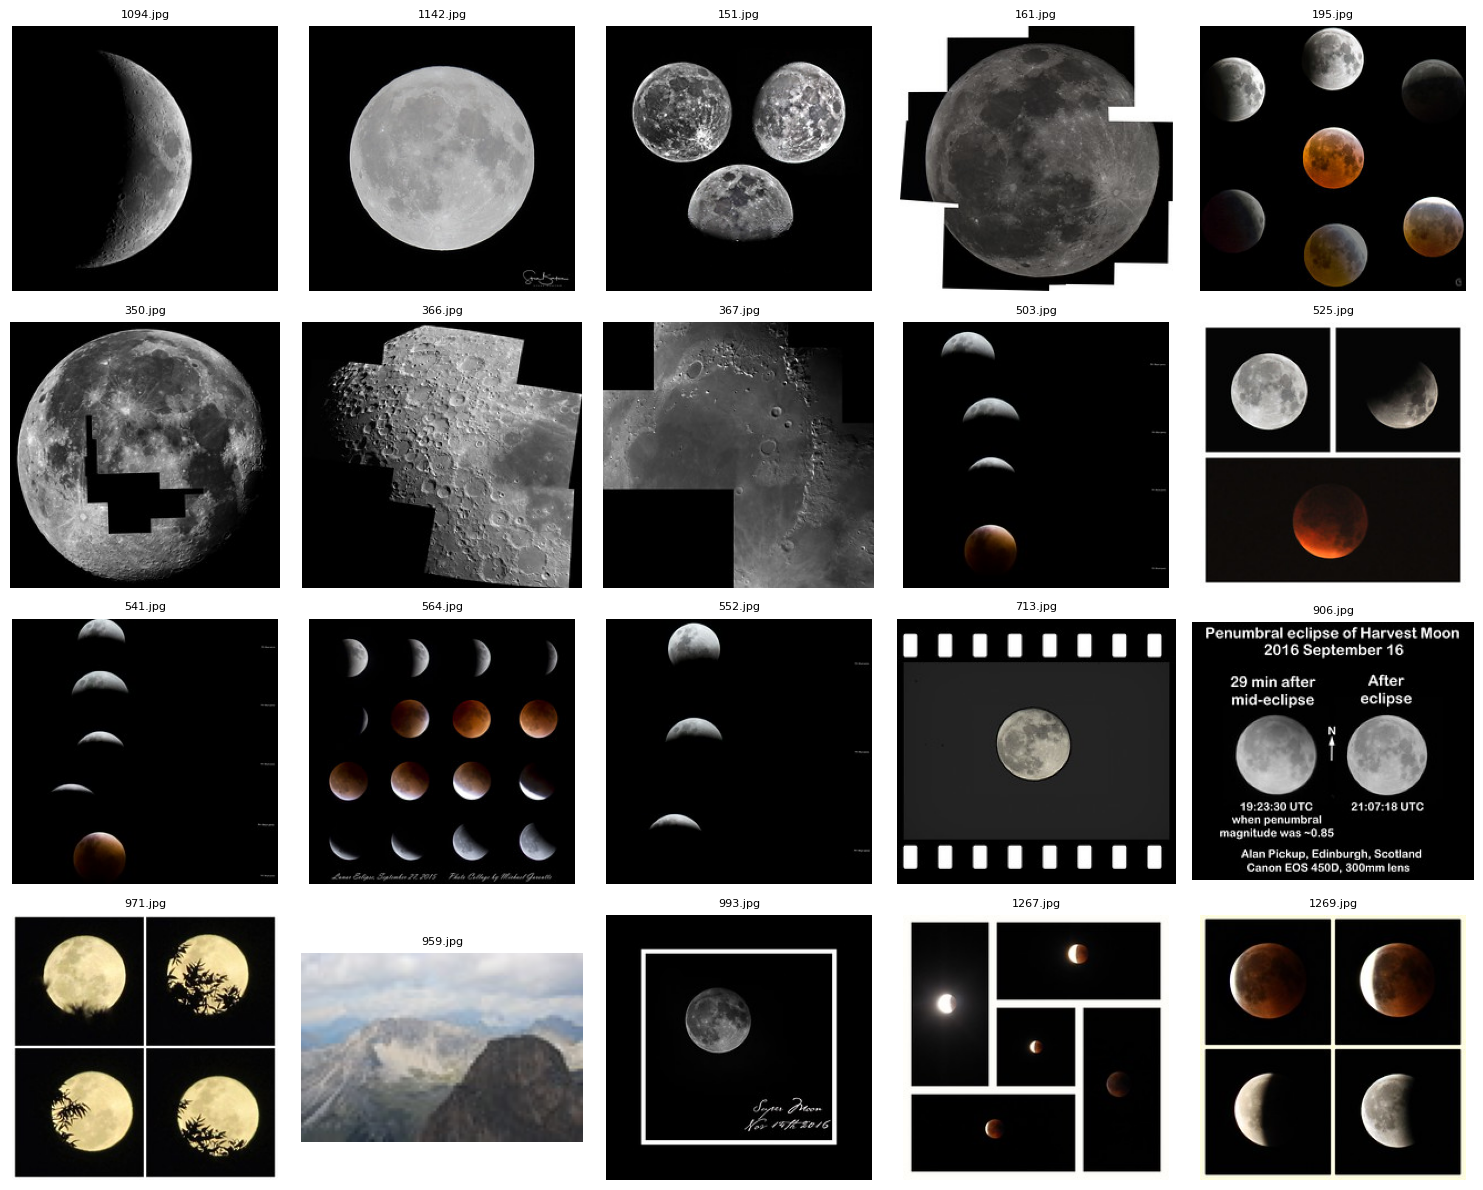

In [5]:
flagged_ids = [109,114,151,161,195,350,366,367,503,525,541,564,552,
               713,906,971,959,993,1267,1269]

def find_file(file_list,id_):
    for p in file_list:
        fname = os.path.basename(p)
        if fname == f"{id_}.jpg" or fname.startswith(f"{id_}") or f"_{id_}." in fname:
            return p
    return None

flagged_paths = []
for id_ in flagged_ids:
    fp = find_file(path,id_)
    if fp:
        flagged_paths.append(fp)
    else:
        print(f"Could not find file for {id_}")

print(f"Found{len(flagged_paths)}/{len(flagged_ids)} flagged files")

n = len(flagged_paths)
cols = 5
rows = (n + cols - 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(15, 3*rows))
axes = axes.flatten()

for i, fp in enumerate(flagged_paths):
    img = Image.open(fp)
    axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
    axes[i].set_title(os.path.basename(fp), fontsize=8)
    axes[i].axis('off')

for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


Voila! I guess it's obvious why we must've removed these..

In [6]:
def remove_flagged(file_list,flagged_ids):
    removed = []
    remaining = []
    for p in file_list:
        fname = os.path.basename(p)
        id_ = os.path.splitext(fname)[0]
        try:
            id_num = int(id_.split('_')[-1]if '_' in id_ else int(id_))
        except ValueError:
            id_num = None

        if id_num in flagged_ids:
            removed.append(p)
        else:
            remaining.append(p)

    print(f"Flagged for removal: {len(removed)}")
    for p in removed:
        os.remove(p)
    return remaining

path = remove_flagged(path,flagged_ids)

Flagged for removal: 20


Treating as grayscale (1 channel) and image size = 64 (low res)

In [7]:
out_dir = "data/moon_processed"
os.makedirs(out_dir,exist_ok=True)
IMG_SIZE = 64

def process_grayscale(file_list,out_dir,image_size=64):
    for i,p in enumerate(tqdm(file_list)):
        try:
            img = Image.open(p).convert("L")
        except Exception:
            continue
        w,h = img.size
        scale = image_size/min(w,h)
        img = img.resize((int(w*scale),int(h*scale)), Image.LANCZOS)
        w2,h2 = img.size
        left,top = (w2-image_size)//2,(h2-image_size)//2
        img = img.crop((left,top,left+image_size,top+image_size))
        img.save(os.path.join(out_dir,f"moon_{i:05d}.png"))

process_grayscale(path,out_dir,IMG_SIZE)

100%|██████████| 1324/1324 [00:01<00:00, 677.82it/s]


In [8]:
class MoonDataset(Dataset):
    def __init__(self,root_dir,image_size=64,channels=1):
        self.files = glob.glob(os.path.join(root_dir,'*.png'))
        self.channels = channels
        mean = [0.5]*channels
        std = [0.5]*channels
        self.transform = T.Compose([
            T.Resize((image_size,image_size)),
            T.RandomHorizontalFlip(),
            T.ToTensor(),
            T.Normalize(mean,std)
        ])
    def __len__(self):
        return len(self.files)

    def __getitem__(self,idx):
        img = Image.open(self.files[idx]).convert("L")
        return self.transform(img)

dataset = MoonDataset(out_dir,image_size=IMG_SIZE,channels=1)
dataloader = DataLoader(dataset,batch_size=64,shuffle=True,num_workers=4,pin_memory=True,drop_last=True)
batch = next(iter(dataloader))
print(batch.shape,batch.min().item(),batch.max().item())

torch.Size([64, 1, 64, 64]) -1.0 1.0


Now I'm gonna check the images again after grayscaling, cropping, normalising, flipping to make the model learn with more variance to avoid overfitting. It's important that I check this is because this is the final version of the images through which my model will learn.

Batch Shape: torch.Size([64, 1, 64, 64])
Value range: <built-in method item of Tensor object at 0x7c98a8172d00> to 1.0


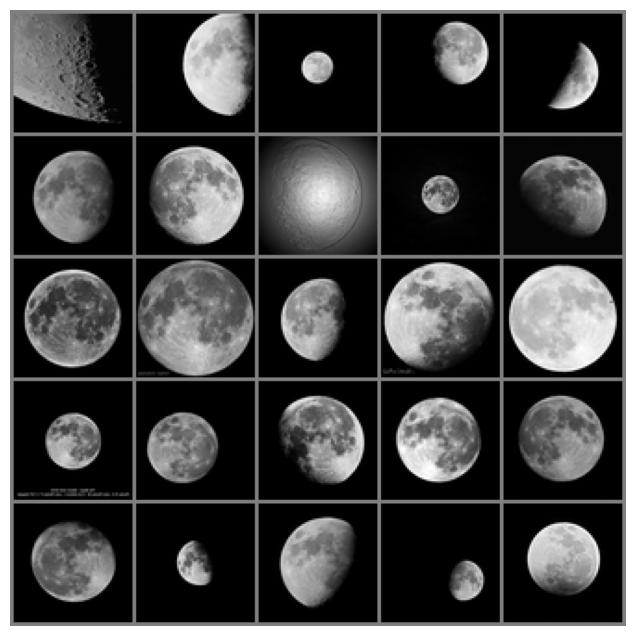

In [9]:
batch = next(iter(dataloader))
print("Batch Shape:", batch.shape)
print("Value range:",batch.min().item,"to",batch.max().item())

grid = vutils.make_grid(batch[:25],nrow=5,normalize=False)
grid_display = (grid+1)/2

plt.figure(figsize=(8,8))
plt.imshow(grid_display.permute(1,2,0).squeeze(),cmap='gray')
plt.axis('off')
plt.show()

Nice, as expected. Now we shall start the real deals!

### Forward Process: Noise Scheduling. I'm gonna use the Cosine Beta Schedule instead of linear because it aggresively destroys the data by adding noise. Cosine allows the model to learn through the transformations thoroughly.

In [10]:
def linear_beta_schedule(timesteps, start=0.0001, end=0.02):
    return torch.linspace(start,end,timesteps)

def cosine_beta_schedule(timesteps,s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0,timesteps,steps)
    alphas_cumprod = torch.cos(((x/timesteps)+s)/(1+s)*math.pi*0.5)**2
    alphas_cumprod = alphas_cumprod/alphas_cumprod[0]
    betas = 1-(alphas_cumprod[1:]/alphas_cumprod[:-1])
    return torch.clip(betas,0.0001,0.9999)

def get_index_from_list(vals,t,x_shape):
    batch_size = t.shape[0]
    out = vals.gather(-1,t.cpu())
    return out.reshape(batch_size,*((1,)*(len(x_shape)-1))).to(t.device)

def forward_diffusion_sample(x_0,t,device="cpu"):
    noise = torch.randn_like(x_0)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod,t,x_0.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(
        sqrt_one_minus_alphas_cumprod,t,x_0.shape
    )
    return sqrt_alphas_cumprod_t.to(device)*x_0.to(device)\
    +sqrt_one_minus_alphas_cumprod_t.to(device)*noise.to(device),noise.to(device)

T_STEPS = 150
SCHEDULE = "cosine"
if SCHEDULE == "cosine":
    betas = cosine_beta_schedule(timesteps=T_STEPS)
else:
    betas = linear_beta_schedule(timesteps=T_STEPS)

alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas,axis=0)
alphas_cumprod_prev = F.pad(alphas_cumprod[:-1],(1,0),value=1.0)
sqrt_recip_alias = torch.sqrt(1.0/alphas)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.-alphas_cumprod)
posterior_variance = betas * (1. - alphas_cumprod_prev)/(1.-alphas_cumprod)


I'm gonna plot my Beta Schedule and the Cumulative Alpha, so that I can see how it looks and everything's going as intended.

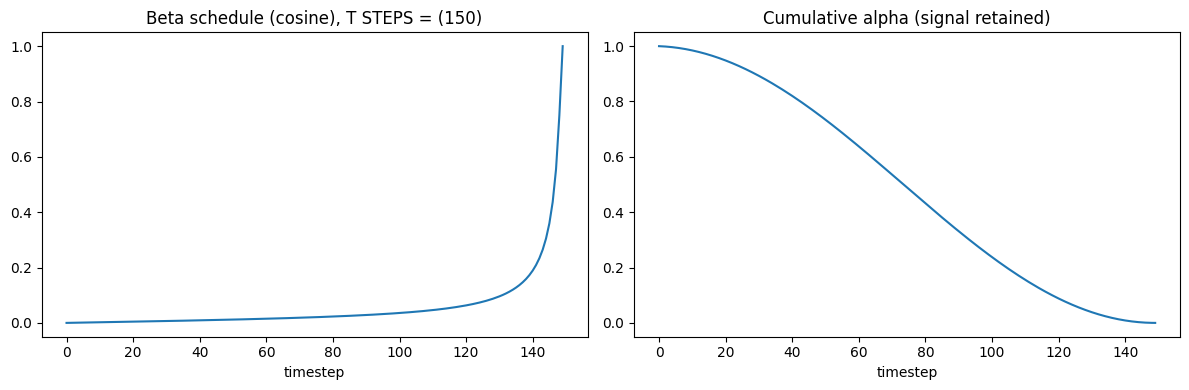

In [11]:
fig,axes = plt.subplots(1,2,figsize=(12,4))
axes[0].plot(betas.numpy())
axes[0].set_title(f"Beta schedule ({SCHEDULE}), T STEPS = ({T_STEPS})")
axes[0].set_xlabel("timestep")

axes[1].plot(alphas_cumprod.numpy())
axes[1].set_title("Cumulative alpha (signal retained)")
axes[1].set_xlabel("timestep")

plt.tight_layout()
plt.show()

That's clean now we shall start our noise scheduling.

In [12]:
def show_tensor_image(image):
    reverse_transforms = T.Compose([
        T.Lambda(lambda t: (t+1)/2),
        T.Lambda(lambda t: t.clamp(0,1)),
        T.Lambda(lambda t: t.permute(1,2,0)),
        T.Lambda(lambda t: t* 255.),
        T.Lambda(lambda t: t.numpy().astype(np.uint8)),
        T.Lambda(lambda t: t.squeeze(-1) if t.shape[-1]==1 else t),
        T.ToPILImage(),
    ])
    if len(image.shape) == 4:
        image = image[0,:,:,:]
    plt.imshow(reverse_transforms(image.cpu()),cmap="gray")

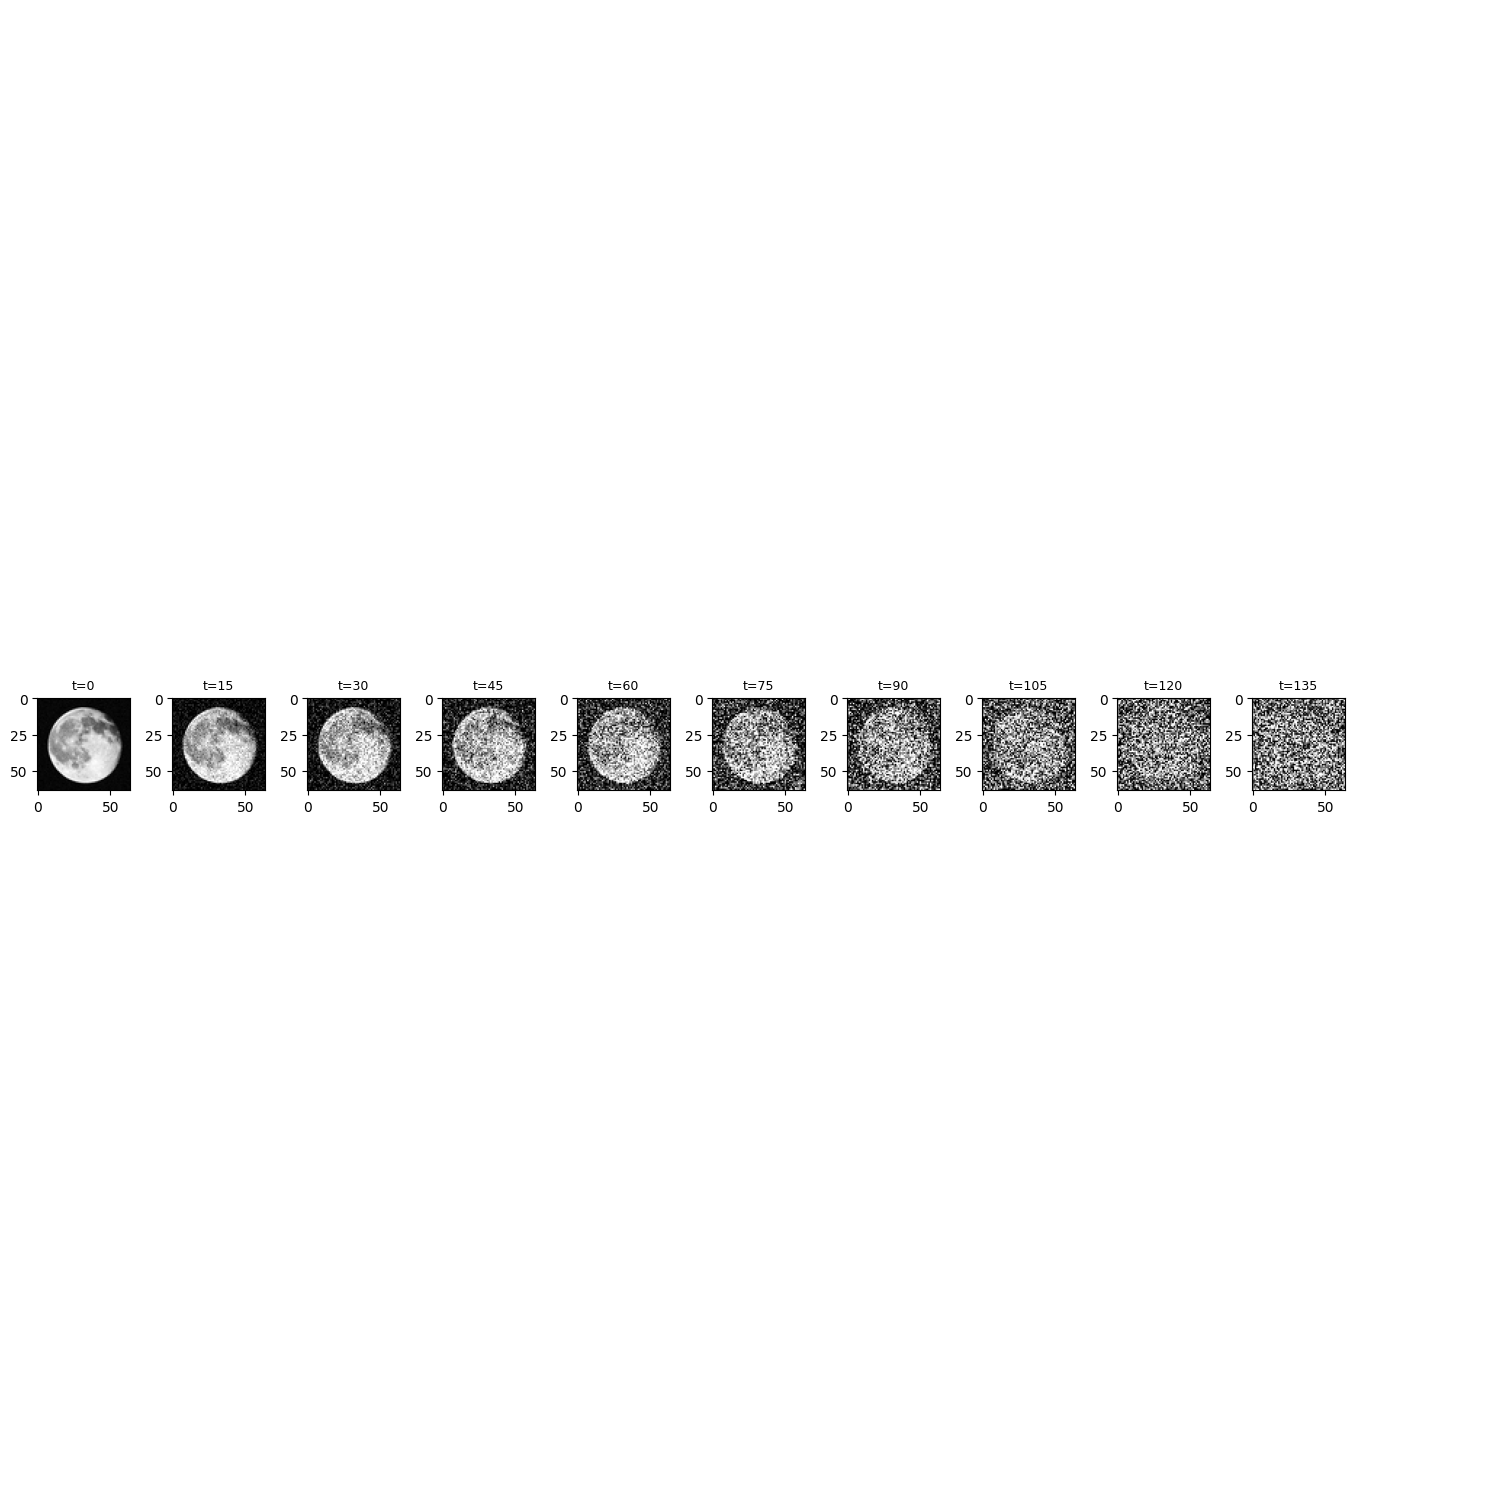

In [13]:
image = next(iter(dataloader))[0]

plt.figure(figsize=(15,15))
plt.axis('off')
num_images = 10
stepsize = int(T_STEPS/num_images)

for idx in range(0,T_STEPS,stepsize):
    t = torch.Tensor([idx]).type(torch.int64)
    plt.subplot(1,num_images + 1, int(idx/stepsize)+1)
    img,noise = forward_diffusion_sample(image,t)
    show_tensor_image(img)
    plt.title(f"t={idx}",fontsize=9)

plt.tight_layout()
plt.show()

As we can see our image is gradually becoming more noisier with each time step, I've kept only 150 time steps for this small experiment which would yeild lower quality results but we can expect it to learn through the important features as there is only one object in the entire dataset.

### Backward Process: Model Architecture -> UNet with self-attention

In [14]:
class SinusoidalPositionEmbeddings(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = math.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class Block(nn.Module):
    def __init__(self, in_ch, out_ch, time_emb_dim, up=False, groups=8):
        super().__init__()
        self.time_mlp = nn.Linear(time_emb_dim, out_ch)

        if up:
            self.conv1 = nn.Conv2d(2 * in_ch, out_ch, 3, padding=1)
            self.transform = nn.ConvTranspose2d(out_ch, out_ch, 4, 2, 1)
            self.res_proj = nn.Conv2d(2 * in_ch, out_ch, 1)
        else:
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1)
            self.transform = nn.Conv2d(out_ch, out_ch, 4, 2, 1)
            self.res_proj = nn.Conv2d(in_ch, out_ch, 1)

        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1)
        self.norm1 = nn.GroupNorm(groups, out_ch)
        self.norm2 = nn.GroupNorm(groups, out_ch)
        self.act = nn.SiLU()

    def forward(self, x, t):
        residual = self.res_proj(x)

        h = self.norm1(self.act(self.conv1(x)))
        time_emb = self.act(self.time_mlp(t))
        time_emb = time_emb[(..., ) + (None, ) * 2]
        h = h + time_emb
        h = self.norm2(self.act(self.conv2(h)))

        h = h + residual
        return self.transform(h)


class SelfAttention(nn.Module):
    def __init__(self, channels, groups=8):
        super().__init__()
        self.norm = nn.GroupNorm(groups, channels)
        self.qkv = nn.Conv2d(channels, channels * 3, 1)
        self.proj = nn.Conv2d(channels, channels, 1)
        self.scale = channels ** -0.5

    def forward(self, x):
        B, C, H, W = x.shape
        h = self.norm(x)
        qkv = self.qkv(h).reshape(B, 3, C, H * W)
        q, k, v = qkv[:, 0], qkv[:, 1], qkv[:, 2]

        attn = torch.softmax((q.transpose(1, 2) @ k) * self.scale, dim=-1)
        out = v @ attn.transpose(1, 2)
        out = out.reshape(B, C, H, W)
        return x + self.proj(out)


class MoonUnet(nn.Module):
    def __init__(self, image_channels=1, time_emb_dim=64):
        super().__init__()
        down_channels = (32, 64, 128, 256)
        up_channels = (256, 128, 64, 32)
        out_dim = image_channels

        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.SiLU()
        )

        self.conv0 = nn.Conv2d(image_channels, down_channels[0], 3, padding=1)

        self.downs = nn.ModuleList([
            Block(down_channels[i], down_channels[i + 1], time_emb_dim)
            for i in range(len(down_channels) - 1)
        ])

        self.bottleneck_attn = SelfAttention(down_channels[-1])

        self.ups = nn.ModuleList([
            Block(up_channels[i], up_channels[i + 1], time_emb_dim, up=True)
            for i in range(len(up_channels) - 1)
        ])

        self.output = nn.Conv2d(up_channels[-1], out_dim, 1)

    def forward(self, x, timestep):
        t = self.time_mlp(timestep)
        x = self.conv0(x)

        residual_inputs = []
        for down in self.downs:
            x = down(x, t)
            residual_inputs.append(x)

        x = self.bottleneck_attn(x)

        for up in self.ups:
            residual_x = residual_inputs.pop()
            x = torch.cat((x, residual_x), dim=1)
            x = up(x, t)

        return self.output(x)


model = MoonUnet()
print("Num params:", sum(p.numel() for p in model.parameters()))
model


Num params: 4295489


MoonUnet(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): SiLU()
  )
  (conv0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (downs): ModuleList(
    (0): Block(
      (time_mlp): Linear(in_features=64, out_features=64, bias=True)
      (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(64, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
      (res_proj): Conv2d(32, 64, kernel_size=(1, 1), stride=(1, 1))
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (norm1): GroupNorm(8, 64, eps=1e-05, affine=True)
      (norm2): GroupNorm(8, 64, eps=1e-05, affine=True)
      (act): SiLU()
    )
    (1): Block(
      (time_mlp): Linear(in_features=64, out_features=128, bias=True)
      (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (transform): Conv2d(128, 128, ker

Nice, our model will have around 4 million parameters, that's really small. Now let us create the training and sampling loop


In [16]:
@torch.no_grad()
def sample_timestep(model, x, t):
    betas_t = get_index_from_list(betas, t, x.shape)
    sqrt_one_minus_alphas_cumprod_t = get_index_from_list(sqrt_one_minus_alphas_cumprod, t, x.shape)
    sqrt_alphas_cumprod_t = get_index_from_list(sqrt_alphas_cumprod, t, x.shape)
    sqrt_recip_alphas_t = get_index_from_list(sqrt_recip_alias, t, x.shape)

    pred_noise = model(x, t)

    x0_pred = (x - sqrt_one_minus_alphas_cumprod_t * pred_noise) / sqrt_alphas_cumprod_t
    x0_pred = torch.clamp(x0_pred, -1.0, 1.0)

    pred_noise = (x - sqrt_alphas_cumprod_t * x0_pred) / sqrt_one_minus_alphas_cumprod_t

    model_mean = sqrt_recip_alphas_t * (x - betas_t * pred_noise / sqrt_one_minus_alphas_cumprod_t)

    posterior_variance_t = get_index_from_list(posterior_variance, t, x.shape)
    if t[0] == 0:
        return model_mean
    noise = torch.randn_like(x)
    return model_mean + torch.sqrt(posterior_variance_t) * noise
    
@torch.no_grad()
def sample_plot_image(model,n=6):
    img = torch.randn((n,1,64,64),device="cuda")
    for i in range(0,T_STEPS)[::-1]:
        t = torch.full((n,),i,device="cuda",dtype=torch.long)
        img = sample_timestep(model,img,t)

    fig,axes = plt.subplots(1,n,figsize=(2*n,2))
    for k in range(n):
        show_tensor_image(img[k].unsqueeze(0))
        axes[k].axis('off') if hasattr(axes,'__len__') else None
    plt.tight_layout()
    plt.show()


It's usually better to stop execution manually when we reach the best loss but I'm using average loss < minimum loss condition here. Our batch size is 128 and we will train for 500 epochs.

Epoch 000 | Loss: 0.7362


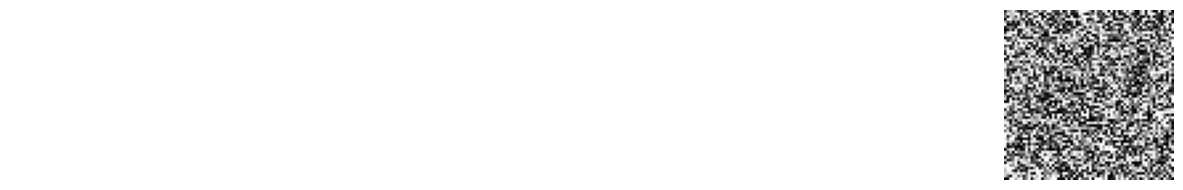

Epoch 001 | Loss: 0.5969
Epoch 002 | Loss: 0.4859
Epoch 003 | Loss: 0.3817
Epoch 004 | Loss: 0.3049
Epoch 005 | Loss: 0.2741
Epoch 006 | Loss: 0.2558
Epoch 007 | Loss: 0.2434
Epoch 008 | Loss: 0.2272
Epoch 009 | Loss: 0.2134
Epoch 010 | Loss: 0.2076
Epoch 011 | Loss: 0.2050
Epoch 012 | Loss: 0.1983
Epoch 013 | Loss: 0.1894
Epoch 014 | Loss: 0.1883
Epoch 015 | Loss: 0.1857
Epoch 016 | Loss: 0.1848
Epoch 017 | Loss: 0.1774
Epoch 018 | Loss: 0.1776
Epoch 019 | Loss: 0.1771
Epoch 020 | Loss: 0.1695
Epoch 021 | Loss: 0.1656
Epoch 022 | Loss: 0.1684
Epoch 023 | Loss: 0.1672
Epoch 024 | Loss: 0.1631
Epoch 025 | Loss: 0.1624


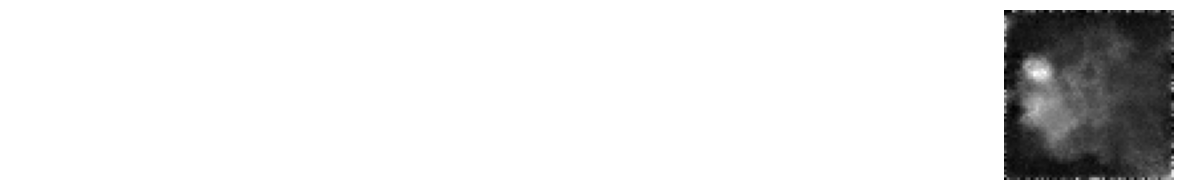

Epoch 026 | Loss: 0.1589
Epoch 027 | Loss: 0.1562
Epoch 028 | Loss: 0.1569
Epoch 029 | Loss: 0.1613
Epoch 030 | Loss: 0.1558
Epoch 031 | Loss: 0.1588
Epoch 032 | Loss: 0.1554
Epoch 033 | Loss: 0.1520
Epoch 034 | Loss: 0.1489
Epoch 035 | Loss: 0.1501
Epoch 036 | Loss: 0.1488
Epoch 037 | Loss: 0.1503
Epoch 038 | Loss: 0.1481
Epoch 039 | Loss: 0.1507
Epoch 040 | Loss: 0.1473
Epoch 041 | Loss: 0.1447
Epoch 042 | Loss: 0.1460
Epoch 043 | Loss: 0.1454
Epoch 044 | Loss: 0.1480
Epoch 045 | Loss: 0.1445
Epoch 046 | Loss: 0.1392
Epoch 047 | Loss: 0.1331
Epoch 048 | Loss: 0.1407
Epoch 049 | Loss: 0.1374
Epoch 050 | Loss: 0.1363


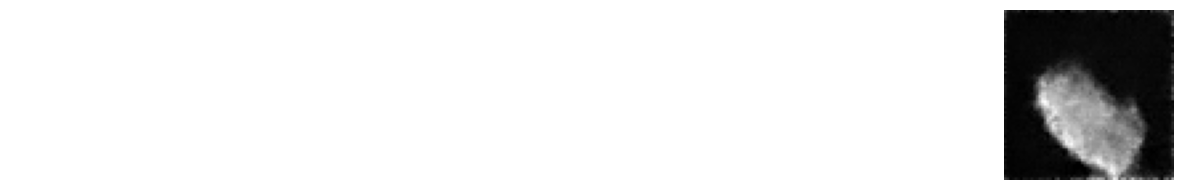

Epoch 051 | Loss: 0.1376
Epoch 052 | Loss: 0.1419
Epoch 053 | Loss: 0.1425
Epoch 054 | Loss: 0.1371
Epoch 055 | Loss: 0.1304
Epoch 056 | Loss: 0.1381
Epoch 057 | Loss: 0.1340
Epoch 058 | Loss: 0.1382
Epoch 059 | Loss: 0.1316
Epoch 060 | Loss: 0.1338
Epoch 061 | Loss: 0.1263
Epoch 062 | Loss: 0.1324
Epoch 063 | Loss: 0.1268
Epoch 064 | Loss: 0.1293
Epoch 065 | Loss: 0.1297
Epoch 066 | Loss: 0.1289
Epoch 067 | Loss: 0.1301
Epoch 068 | Loss: 0.1248
Epoch 069 | Loss: 0.1272
Epoch 070 | Loss: 0.1277
Epoch 071 | Loss: 0.1261
Epoch 072 | Loss: 0.1211
Epoch 073 | Loss: 0.1189
Epoch 074 | Loss: 0.1281
Epoch 075 | Loss: 0.1238


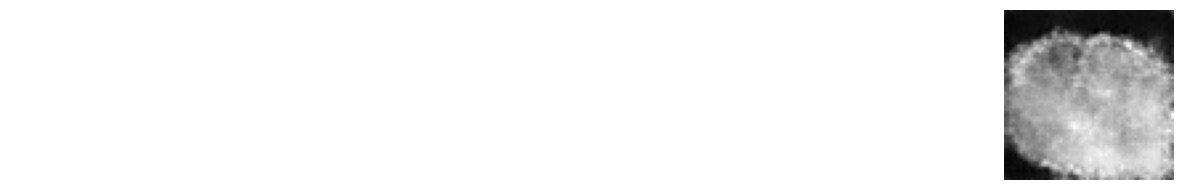

Epoch 076 | Loss: 0.1218
Epoch 077 | Loss: 0.1235
Epoch 078 | Loss: 0.1182
Epoch 079 | Loss: 0.1205
Epoch 080 | Loss: 0.1162
Epoch 081 | Loss: 0.1168
Epoch 082 | Loss: 0.1184
Epoch 083 | Loss: 0.1163
Epoch 084 | Loss: 0.1192
Epoch 085 | Loss: 0.1178
Epoch 086 | Loss: 0.1183
Epoch 087 | Loss: 0.1124
Epoch 088 | Loss: 0.1110
Epoch 089 | Loss: 0.1132
Epoch 090 | Loss: 0.1151
Epoch 091 | Loss: 0.1153
Epoch 092 | Loss: 0.1132
Epoch 093 | Loss: 0.1136
Epoch 094 | Loss: 0.1119
Epoch 095 | Loss: 0.1144
Epoch 096 | Loss: 0.1064
Epoch 097 | Loss: 0.1137
Epoch 098 | Loss: 0.1097
Epoch 099 | Loss: 0.1115
Epoch 100 | Loss: 0.1162


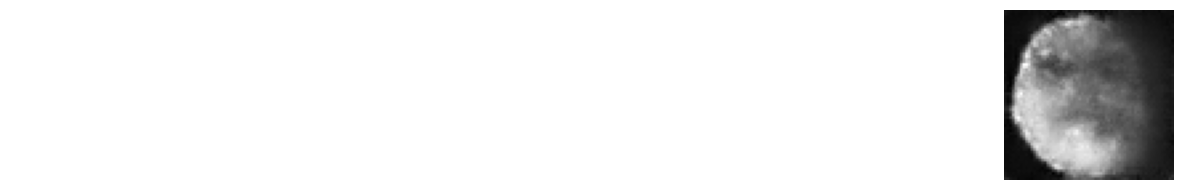

Epoch 101 | Loss: 0.1100
Epoch 102 | Loss: 0.1083
Epoch 103 | Loss: 0.1016
Epoch 104 | Loss: 0.1041
Epoch 105 | Loss: 0.1076
Epoch 106 | Loss: 0.1077
Epoch 107 | Loss: 0.1076
Epoch 108 | Loss: 0.1092
Epoch 109 | Loss: 0.1079
Epoch 110 | Loss: 0.1067
Epoch 111 | Loss: 0.1076
Epoch 112 | Loss: 0.1054
Epoch 113 | Loss: 0.1057
Epoch 114 | Loss: 0.1075
Epoch 115 | Loss: 0.1015
Epoch 116 | Loss: 0.1062
Epoch 117 | Loss: 0.1086
Epoch 118 | Loss: 0.1080
Epoch 119 | Loss: 0.1073
Epoch 120 | Loss: 0.1041
Epoch 121 | Loss: 0.1025
Epoch 122 | Loss: 0.1045
Epoch 123 | Loss: 0.1083
Epoch 124 | Loss: 0.1082
Epoch 125 | Loss: 0.1029


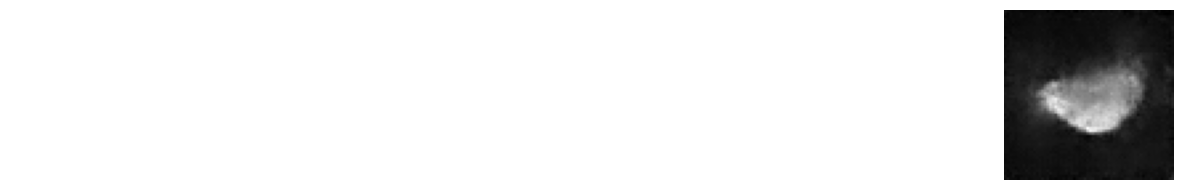

Epoch 126 | Loss: 0.1084
Epoch 127 | Loss: 0.1045
Epoch 128 | Loss: 0.1041
Epoch 129 | Loss: 0.1049
Epoch 130 | Loss: 0.1021
Epoch 131 | Loss: 0.1089
Epoch 132 | Loss: 0.1026
Epoch 133 | Loss: 0.1029
Epoch 134 | Loss: 0.1041
Epoch 135 | Loss: 0.1118
Epoch 136 | Loss: 0.1070
Epoch 137 | Loss: 0.1008
Epoch 138 | Loss: 0.1028
Epoch 139 | Loss: 0.1046
Epoch 140 | Loss: 0.1017
Epoch 141 | Loss: 0.1028
Epoch 142 | Loss: 0.1000
Epoch 143 | Loss: 0.0995
Epoch 144 | Loss: 0.1030
Epoch 145 | Loss: 0.1022
Epoch 146 | Loss: 0.1037
Epoch 147 | Loss: 0.1007
Epoch 148 | Loss: 0.1029
Epoch 149 | Loss: 0.1075
Epoch 150 | Loss: 0.1053


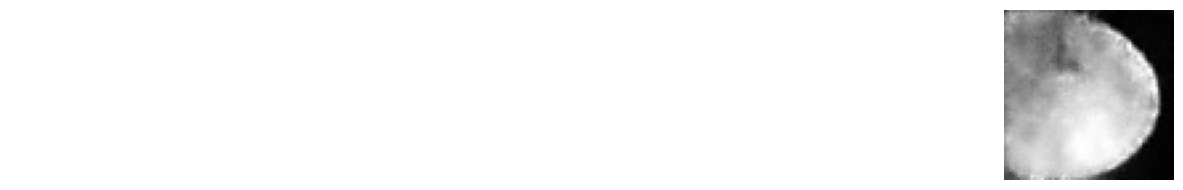

Epoch 151 | Loss: 0.0957
Epoch 152 | Loss: 0.1042
Epoch 153 | Loss: 0.1011
Epoch 154 | Loss: 0.1020
Epoch 155 | Loss: 0.0980
Epoch 156 | Loss: 0.0959
Epoch 157 | Loss: 0.1000
Epoch 158 | Loss: 0.1029
Epoch 159 | Loss: 0.0994
Epoch 160 | Loss: 0.1004
Epoch 161 | Loss: 0.0990
Epoch 162 | Loss: 0.0968
Epoch 163 | Loss: 0.1020
Epoch 164 | Loss: 0.1032
Epoch 165 | Loss: 0.1028
Epoch 166 | Loss: 0.0952
Epoch 167 | Loss: 0.1016
Epoch 168 | Loss: 0.1013
Epoch 169 | Loss: 0.1003
Epoch 170 | Loss: 0.1050
Epoch 171 | Loss: 0.1014
Epoch 172 | Loss: 0.1005
Epoch 173 | Loss: 0.0995
Epoch 174 | Loss: 0.1056
Epoch 175 | Loss: 0.1004


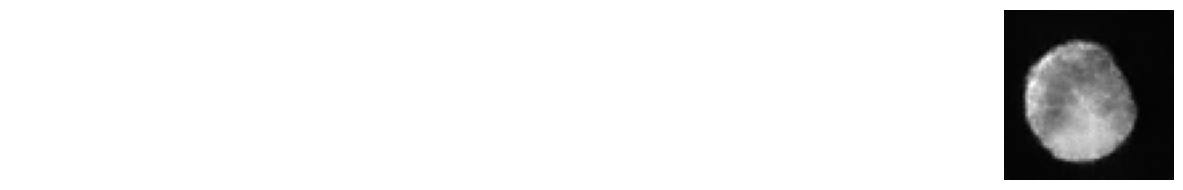

Epoch 176 | Loss: 0.0992
Epoch 177 | Loss: 0.1003
Epoch 178 | Loss: 0.1020
Epoch 179 | Loss: 0.0964
Epoch 180 | Loss: 0.0961
Epoch 181 | Loss: 0.1001
Epoch 182 | Loss: 0.1009
Epoch 183 | Loss: 0.0959
Epoch 184 | Loss: 0.0998
Epoch 185 | Loss: 0.0973
Epoch 186 | Loss: 0.1017
Epoch 187 | Loss: 0.1020
Epoch 188 | Loss: 0.0950
Epoch 189 | Loss: 0.0989
Epoch 190 | Loss: 0.0986
Epoch 191 | Loss: 0.0975
Epoch 192 | Loss: 0.0993
Epoch 193 | Loss: 0.0946
Epoch 194 | Loss: 0.1004
Epoch 195 | Loss: 0.0942
Epoch 196 | Loss: 0.1003
Epoch 197 | Loss: 0.1000
Epoch 198 | Loss: 0.0939
Epoch 199 | Loss: 0.0933
Epoch 200 | Loss: 0.0966


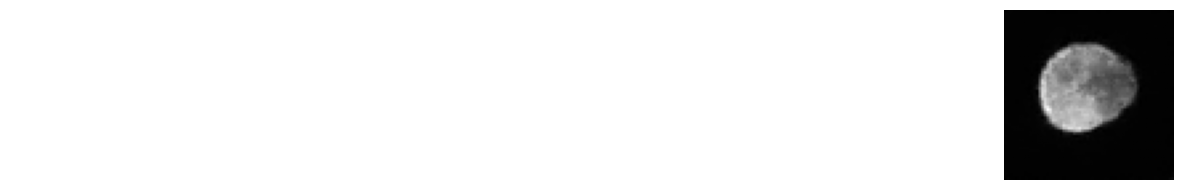

Epoch 201 | Loss: 0.1009
Epoch 202 | Loss: 0.1026
Epoch 203 | Loss: 0.0968
Epoch 204 | Loss: 0.1003
Epoch 205 | Loss: 0.0946
Epoch 206 | Loss: 0.0998
Epoch 207 | Loss: 0.0941
Epoch 208 | Loss: 0.0990
Epoch 209 | Loss: 0.0937
Epoch 210 | Loss: 0.1015
Epoch 211 | Loss: 0.0965
Epoch 212 | Loss: 0.0979
Epoch 213 | Loss: 0.0963
Epoch 214 | Loss: 0.0935
Epoch 215 | Loss: 0.0964
Epoch 216 | Loss: 0.0975
Epoch 217 | Loss: 0.0950
Epoch 218 | Loss: 0.0968
Epoch 219 | Loss: 0.0912
Epoch 220 | Loss: 0.0951
Epoch 221 | Loss: 0.0954
Epoch 222 | Loss: 0.0925
Epoch 223 | Loss: 0.0934
Epoch 224 | Loss: 0.0934
Epoch 225 | Loss: 0.0938


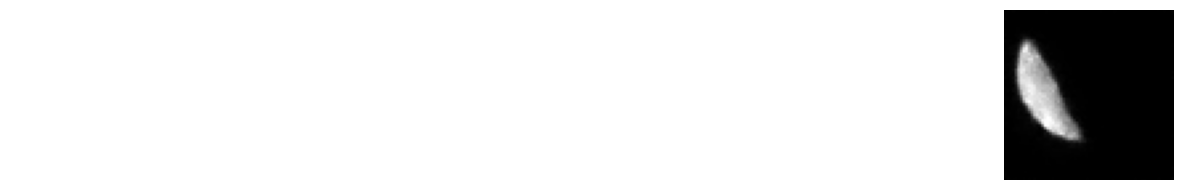

Epoch 226 | Loss: 0.0993
Epoch 227 | Loss: 0.0997
Epoch 228 | Loss: 0.0918
Epoch 229 | Loss: 0.0978
Epoch 230 | Loss: 0.0957
Epoch 231 | Loss: 0.0911
Epoch 232 | Loss: 0.0952
Epoch 233 | Loss: 0.0976
Epoch 234 | Loss: 0.0951
Epoch 235 | Loss: 0.0887
Epoch 236 | Loss: 0.0926
Epoch 237 | Loss: 0.0931
Epoch 238 | Loss: 0.0899
Epoch 239 | Loss: 0.0917
Epoch 240 | Loss: 0.0954
Epoch 241 | Loss: 0.0935
Epoch 242 | Loss: 0.0959
Epoch 243 | Loss: 0.0956
Epoch 244 | Loss: 0.0961
Epoch 245 | Loss: 0.0935
Epoch 246 | Loss: 0.0933
Epoch 247 | Loss: 0.0934
Epoch 248 | Loss: 0.0947
Epoch 249 | Loss: 0.0876
Epoch 250 | Loss: 0.0887


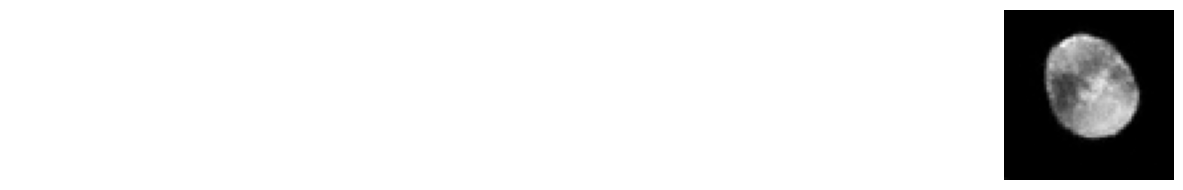

Epoch 251 | Loss: 0.0956
Epoch 252 | Loss: 0.0920
Epoch 253 | Loss: 0.0882
Epoch 254 | Loss: 0.0916
Epoch 255 | Loss: 0.0944
Epoch 256 | Loss: 0.0924
Epoch 257 | Loss: 0.0912
Epoch 258 | Loss: 0.0954
Epoch 259 | Loss: 0.0927
Epoch 260 | Loss: 0.0948
Epoch 261 | Loss: 0.0956
Epoch 262 | Loss: 0.0909
Epoch 263 | Loss: 0.0902
Epoch 264 | Loss: 0.0922
Epoch 265 | Loss: 0.0908
Epoch 266 | Loss: 0.0964
Epoch 267 | Loss: 0.0898
Epoch 268 | Loss: 0.0955
Epoch 269 | Loss: 0.0903
Epoch 270 | Loss: 0.0872
Epoch 271 | Loss: 0.0969
Epoch 272 | Loss: 0.0951
Epoch 273 | Loss: 0.0911
Epoch 274 | Loss: 0.0929
Epoch 275 | Loss: 0.0920


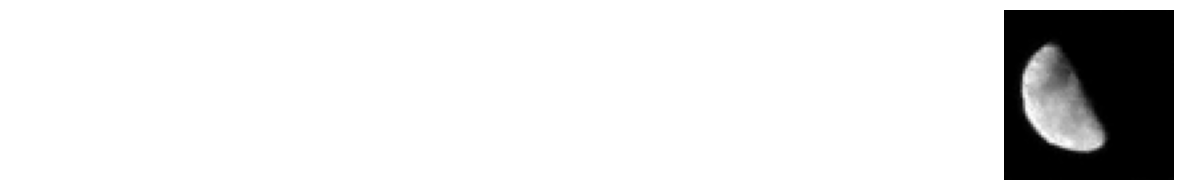

Epoch 276 | Loss: 0.0929
Epoch 277 | Loss: 0.0968
Epoch 278 | Loss: 0.0892
Epoch 279 | Loss: 0.0917
Epoch 280 | Loss: 0.0933
Epoch 281 | Loss: 0.0955
Epoch 282 | Loss: 0.0907
Epoch 283 | Loss: 0.0935
Epoch 284 | Loss: 0.0944
Epoch 285 | Loss: 0.0854
Epoch 286 | Loss: 0.0914
Epoch 287 | Loss: 0.0929
Epoch 288 | Loss: 0.0929
Epoch 289 | Loss: 0.0908
Epoch 290 | Loss: 0.0881
Epoch 291 | Loss: 0.0902
Epoch 292 | Loss: 0.0953
Epoch 293 | Loss: 0.0931
Epoch 294 | Loss: 0.0960
Epoch 295 | Loss: 0.0899
Epoch 296 | Loss: 0.0906
Epoch 297 | Loss: 0.0941
Epoch 298 | Loss: 0.0935
Epoch 299 | Loss: 0.0902
Epoch 300 | Loss: 0.0892


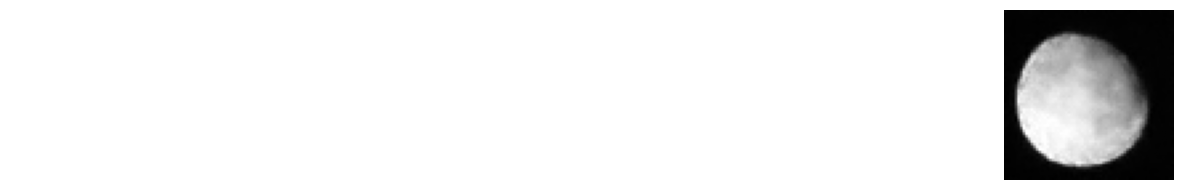

Epoch 301 | Loss: 0.0951
Epoch 302 | Loss: 0.0922
Epoch 303 | Loss: 0.0952
Epoch 304 | Loss: 0.0909
Epoch 305 | Loss: 0.0891
Epoch 306 | Loss: 0.0892
Epoch 307 | Loss: 0.0906
Epoch 308 | Loss: 0.0888
Epoch 309 | Loss: 0.0904
Epoch 310 | Loss: 0.0936
Epoch 311 | Loss: 0.0896
Epoch 312 | Loss: 0.0896
Epoch 313 | Loss: 0.0939
Epoch 314 | Loss: 0.0907
Epoch 315 | Loss: 0.0939
Epoch 316 | Loss: 0.0825
Epoch 317 | Loss: 0.0898
Epoch 318 | Loss: 0.0890
Epoch 319 | Loss: 0.0867
Epoch 320 | Loss: 0.0894
Epoch 321 | Loss: 0.0912
Epoch 322 | Loss: 0.0893
Epoch 323 | Loss: 0.0903
Epoch 324 | Loss: 0.0927
Epoch 325 | Loss: 0.0895


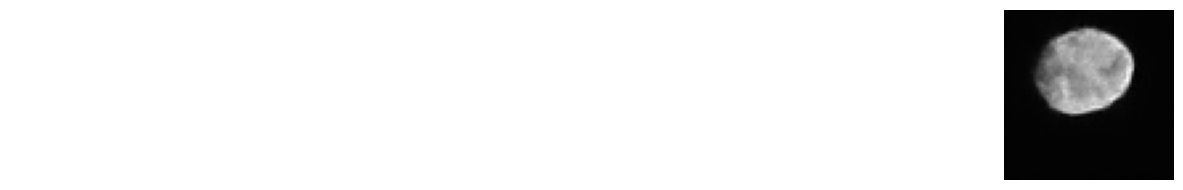

Epoch 326 | Loss: 0.0892
Epoch 327 | Loss: 0.0948
Epoch 328 | Loss: 0.0946
Epoch 329 | Loss: 0.0912
Epoch 330 | Loss: 0.0913
Epoch 331 | Loss: 0.0928
Epoch 332 | Loss: 0.0949
Epoch 333 | Loss: 0.0844
Epoch 334 | Loss: 0.0887
Epoch 335 | Loss: 0.0839
Epoch 336 | Loss: 0.0929
Epoch 337 | Loss: 0.0897
Epoch 338 | Loss: 0.0905
Epoch 339 | Loss: 0.0895
Epoch 340 | Loss: 0.0883
Epoch 341 | Loss: 0.0928
Epoch 342 | Loss: 0.0869
Epoch 343 | Loss: 0.0901
Epoch 344 | Loss: 0.0876
Epoch 345 | Loss: 0.0914
Epoch 346 | Loss: 0.0868
Epoch 347 | Loss: 0.0908
Epoch 348 | Loss: 0.0882
Epoch 349 | Loss: 0.0889
Epoch 350 | Loss: 0.0873


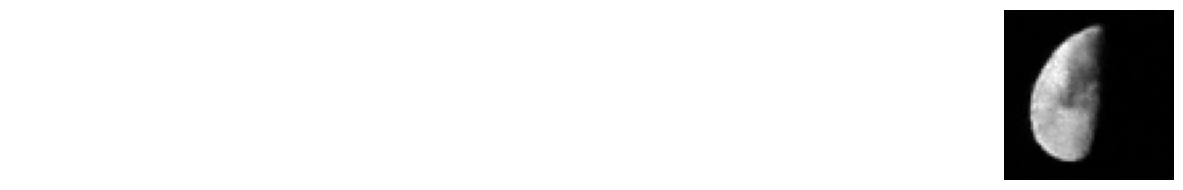

Epoch 351 | Loss: 0.0902
Epoch 352 | Loss: 0.0881
Epoch 353 | Loss: 0.0877
Epoch 354 | Loss: 0.0875
Epoch 355 | Loss: 0.0872
Epoch 356 | Loss: 0.0875
Epoch 357 | Loss: 0.0872
Epoch 358 | Loss: 0.0896
Epoch 359 | Loss: 0.0887
Epoch 360 | Loss: 0.0866
Epoch 361 | Loss: 0.0867
Epoch 362 | Loss: 0.0875
Epoch 363 | Loss: 0.0893
Epoch 364 | Loss: 0.0878
Epoch 365 | Loss: 0.0869
Epoch 366 | Loss: 0.0895
Epoch 367 | Loss: 0.0866
Epoch 368 | Loss: 0.0924
Epoch 369 | Loss: 0.0880
Epoch 370 | Loss: 0.0872
Epoch 371 | Loss: 0.0883
Epoch 372 | Loss: 0.0857
Epoch 373 | Loss: 0.0872
Epoch 374 | Loss: 0.0845
Epoch 375 | Loss: 0.0865


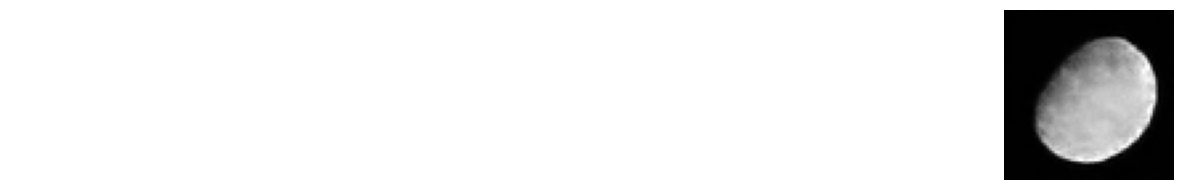

Epoch 376 | Loss: 0.0889
Epoch 377 | Loss: 0.0883
Epoch 378 | Loss: 0.0856
Epoch 379 | Loss: 0.0882
Epoch 380 | Loss: 0.0905
Epoch 381 | Loss: 0.0856
Epoch 382 | Loss: 0.0879
Epoch 383 | Loss: 0.0871
Epoch 384 | Loss: 0.0878
Epoch 385 | Loss: 0.0931
Epoch 386 | Loss: 0.0843
Epoch 387 | Loss: 0.0874
Epoch 388 | Loss: 0.0874
Epoch 389 | Loss: 0.0855
Epoch 390 | Loss: 0.0901
Epoch 391 | Loss: 0.0870
Epoch 392 | Loss: 0.0880
Epoch 393 | Loss: 0.0898
Epoch 394 | Loss: 0.0858
Epoch 395 | Loss: 0.0842
Epoch 396 | Loss: 0.0847
Epoch 397 | Loss: 0.0882
Epoch 398 | Loss: 0.0874
Epoch 399 | Loss: 0.0847
Epoch 400 | Loss: 0.0888


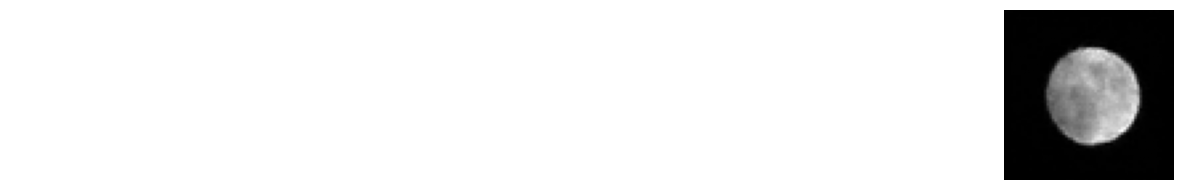

Epoch 401 | Loss: 0.0844
Epoch 402 | Loss: 0.0848
Epoch 403 | Loss: 0.0884
Epoch 404 | Loss: 0.0847
Epoch 405 | Loss: 0.0875
Epoch 406 | Loss: 0.0851
Epoch 407 | Loss: 0.0855
Epoch 408 | Loss: 0.0897
Epoch 409 | Loss: 0.0840
Epoch 410 | Loss: 0.0898
Epoch 411 | Loss: 0.0871
Epoch 412 | Loss: 0.0896
Epoch 413 | Loss: 0.0849
Epoch 414 | Loss: 0.0852
Epoch 415 | Loss: 0.0874
Epoch 416 | Loss: 0.0848
Epoch 417 | Loss: 0.0834
Epoch 418 | Loss: 0.0850
Epoch 419 | Loss: 0.0855
Epoch 420 | Loss: 0.0868
Epoch 421 | Loss: 0.0871
Epoch 422 | Loss: 0.0884
Epoch 423 | Loss: 0.0887
Epoch 424 | Loss: 0.0856
Epoch 425 | Loss: 0.0881


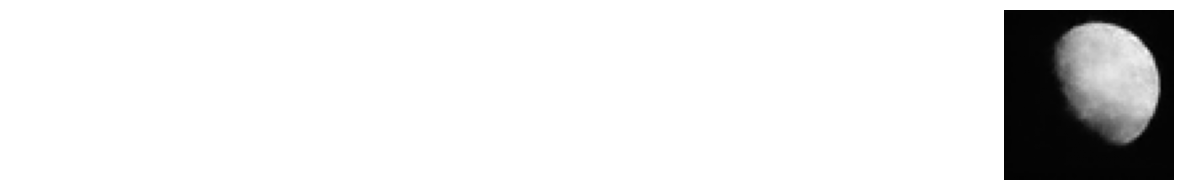

Epoch 426 | Loss: 0.0887
Epoch 427 | Loss: 0.0854
Epoch 428 | Loss: 0.0837
Epoch 429 | Loss: 0.0862
Epoch 430 | Loss: 0.0817
Epoch 431 | Loss: 0.0851
Epoch 432 | Loss: 0.0877
Epoch 433 | Loss: 0.0868
Epoch 434 | Loss: 0.0872
Epoch 435 | Loss: 0.0874
Epoch 436 | Loss: 0.0894
Epoch 437 | Loss: 0.0891
Epoch 438 | Loss: 0.0865
Epoch 439 | Loss: 0.0847
Epoch 440 | Loss: 0.0860


In [ ]:
device = "cuda"

def get_loss(model,x_0,t,device="cpu"):
    x_noisy,noise = forward_diffusion_sample(x_0,t,device)
    noise_pred = model(x_noisy,t)
    return F.l1_loss(noise,noise_pred)

model = MoonUnet().to("cuda")
optimizer = Adam(model.parameters(),lr=1e-4)

BATCH_SIZE = 128
epochs = 500

dataloader = DataLoader(dataset,batch_size=BATCH_SIZE,shuffle=True,num_workers=2,pin_memory=True,drop_last=True)

losses = []
best_loss = float('inf')

for epoch in range(epochs):
    epoch_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        t = torch.randint(0,T_STEPS,(batch.shape[0],),device=device).long()
        loss = get_loss(model,batch.to(device),t,device)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(),max_norm=1.0)
        optimizer.step()
        epoch_loss += loss.item()

    avg_loss = epoch_loss/len(dataloader)
    losses.append(avg_loss)
    print(f"Epoch {epoch:03d}|Loss:{avg_loss:.4f}")

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(),"best_checkpoint.pt")

    if epoch % 25 == 0 or epoch == epochs -1:
        sample_plot_image(model)


Voila, not bad. Here we can see what happens under the hood when a diffusion model generates your images. They start from pure gaussian noise and slowly recreate what they had learnt. Let us generate some samples within this checkpoint.

Generating 64 samples from best_checkpoint.pt...


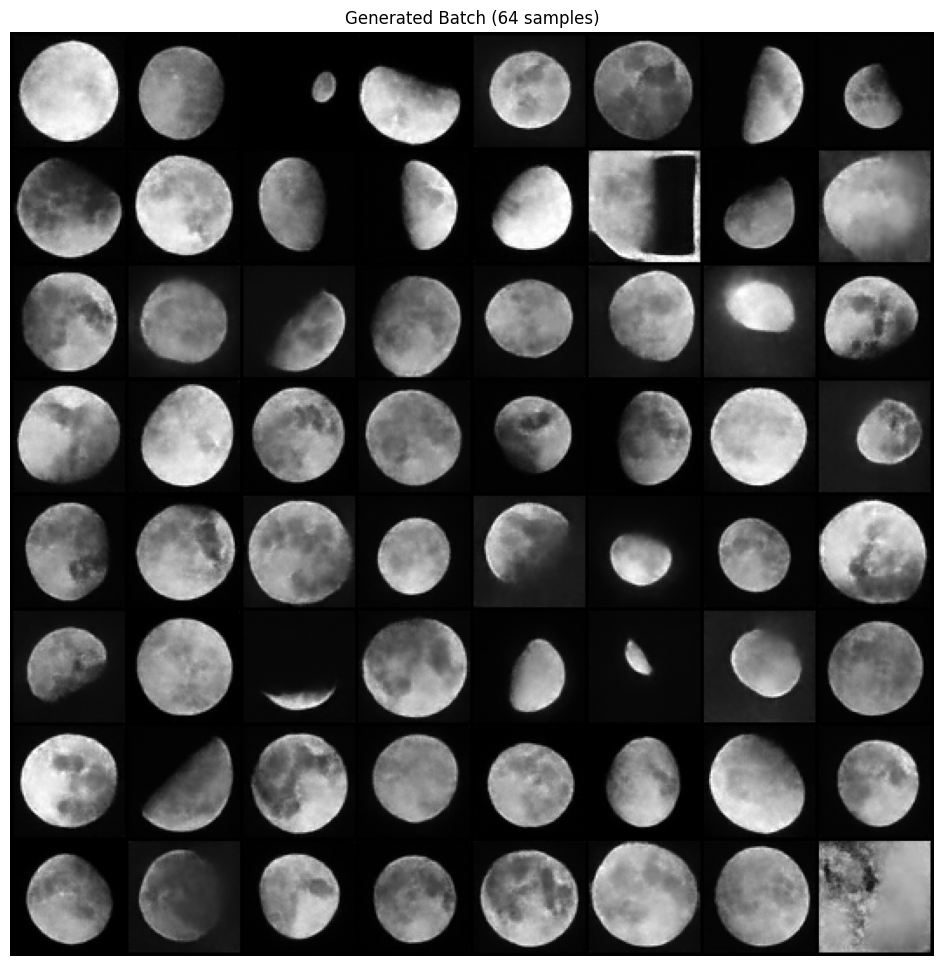

In [22]:
NUM_SAMPLES = 64
ROWS = 8

@torch.no_grad()
def generate_batch(model, n_samples=64):
   
    img = torch.randn((n_samples, 1, 64, 64), device=device)

   
    for i in range(0, T_STEPS)[::-1]:
        t = torch.full((n_samples,), i, device=device, dtype=torch.long)
        img = sample_timestep(model, img, t)

    return img


checkpoint_path = 'best_checkpoint.pt'
if os.path.exists(checkpoint_path):
    inference_model = MoonUnet().to(device)
    inference_model.load_state_dict(torch.load(checkpoint_path))
    inference_model.eval()

    print(f"Generating {NUM_SAMPLES} samples from {checkpoint_path}...")
    samples = generate_batch(inference_model, n_samples=NUM_SAMPLES)

   
    grid = vutils.make_grid(samples, nrow=ROWS, normalize=True, value_range=(-1, 1))

    plt.figure(figsize=(12, 12))
    plt.imshow(grid.permute(1, 2, 0).cpu().squeeze(), cmap='gray')
    plt.title(f"Generated Batch ({NUM_SAMPLES} samples)")
    plt.axis('off')
    plt.show()
else:
    print("Checkpoint not found.")

Wow, although the model was successfull in learning through the shapes/textures of the moon there's still some poor samples which is expected for now. I'm gonna tune the parameters again next time for better results.